<a href="https://colab.research.google.com/github/nevaselvakumar-source/ExtendedEssay/blob/main/plotstrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook we will use to pull the GW collicion data for analysis. The data is from this url [zendo records](https://zenodo.org/records/17014085)

In [ ]:
from IPython.display import display as print
!pip install gwosc gwpy matplotlib pycbc ligo.skymap "pesummary>=0.13.2" pepredicates p_astro

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 7.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.6/320.6 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.0/191.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
%%bash
apt-get update -qq && apt-get install -qq -y libgsl-dev
pip install pyseobnr

Selecting previously unselected package libgslcblas0:amd64.
(Reading database ... 118252 files and directories currently installed.)
Preparing to unpack .../libgslcblas0_2.7.1+dfsg-3_amd64.deb ...
Unpacking libgslcblas0:amd64 (2.7.1+dfsg-3) ...
Selecting previously unselected package libgsl27:amd64.
Preparing to unpack .../libgsl27_2.7.1+dfsg-3_amd64.deb ...
Unpacking libgsl27:amd64 (2.7.1+dfsg-3) ...
Selecting previously unselected package libgsl-dev.
Preparing to unpack .../libgsl-dev_2.7.1+dfsg-3_amd64.deb ...
Unpacking libgsl-dev (2.7.1+dfsg-3) ...
Setting up libgslcblas0:amd64 (2.7.1+dfsg-3) ...
Setting up libgsl27:amd64 (2.7.1+dfsg-3) ...
Setting up libgsl-dev (2.7.1+dfsg-3) ...
Processing triggers for man-db (2.10.2-1) ...
Processing triggers for libc-bin (2.35-0ubuntu3.13) ...
/sbin/ldconfig.real: /usr/local/lib/libhwloc.so.15 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libumf.so.1 is 

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
import matplotlib.pyplot as plt
import pesummary
from pesummary.io import read as pe_read
import h5py
import numpy as np
%matplotlib inline
%config InlineBackend.figure_format='retina'

/usr/local/lib/python3.12/dist-packages/gwpy/time/_ligotimegps.py:42: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [ ]:
# Create the directory if it doesn't exist
import os
if not os.path.exists('./parameter_estimation'):
    os.makedirs('./parameter_estimation')

In [ ]:
# Define the path to the data directory
pathToData = './parameter_estimation/'

In [ ]:
#gw_event = 'GW231226_101520'
# Duplicate this cell for different GW events
pe_gw_url =  'https://zenodo.org/records/17014085/files/IGWN-GWTC4p0-1a206db3d_721-GW231226_101520-combined_PEDataRelease.hdf5?download=1'
gw_file = 'IGWN-GWTC4p0-1a206db3d_721-GW231226_101520-combined_PEDataRelease.hdf5'

!wget -O {pathToData}{gw_file} {pe_gw_url}
gw_file_path = pathToData + gw_file
data = pe_read(gw_file_path)

--2026-05-17 17:28:34--  https://zenodo.org/records/17014085/files/IGWN-GWTC4p0-1a206db3d_721-GW231226_101520-combined_PEDataRelease.hdf5?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.185.43.153, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 575481558 (549M) [application/octet-stream]
Saving to: ‘./parameter_estimation/IGWN-GWTC4p0-1a206db3d_721-GW231226_101520-combined_PEDataRelease.hdf5’

./parameter_estimat 100%[===================>] 548.82M  18.0MB/s    in 31s     

2026-05-17 17:29:06 (17.7 MB/s) - ‘./parameter_estimation/IGWN-GWTC4p0-1a206db3d_721-GW231226_101520-combined_PEDataRelease.hdf5’ saved [575481558/575481558]



In [41]:
#gw_event = 'GW230824_033047'
# Duplicate this cell for different GW events
pe_gw_url =  'https://zenodo.org/records/17014085/files/IGWN-GWTC4p0-1a206db3d_721-GW230824_033047-combined_PEDataRelease.hdf5?download=1'
gw_file = 'IGWN-GWTC4p0-1a206db3d_721-GW230824_033047-combined_PEDataRelease.hdf5'

!wget -O {pathToData}{gw_file} {pe_gw_url}
gw_file_path = pathToData + gw_file
data = pe_read(gw_file_path)

--2026-05-17 19:17:51--  https://zenodo.org/records/17014085/files/IGWN-GWTC4p0-1a206db3d_721-GW230824_033047-combined_PEDataRelease.hdf5?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 137.138.52.235, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 126672656 (121M) [application/octet-stream]
Saving to: ‘./parameter_estimation/IGWN-GWTC4p0-1a206db3d_721-GW230824_033047-combined_PEDataRelease.hdf5’

./parameter_estimat 100%[===================>] 120.80M  22.1MB/s    in 6.8s    

2026-05-17 19:17:58 (17.8 MB/s) - ‘./parameter_estimation/IGWN-GWTC4p0-1a206db3d_721-GW230824_033047-combined_PEDataRelease.hdf5’ saved [126672656/126672656]



In [42]:
print(data.labels)

['C00:IMRPhenomXPHM-SpinTaylor',
 'C00:Mixed',
 'C00:NRSur7dq4',
 'C00:SEOBNRv5PHM']

In [43]:
samples_dict = data.samples_dict
approximant = "SEOBNRv5PHM"
delta_t = 1. / 8192
f_low = 10.
waveforms = samples_dict[f"C00:{approximant}"].maxL_td_waveform(approximant, delta_t, f_low, f_ref=f_low, project="L1")

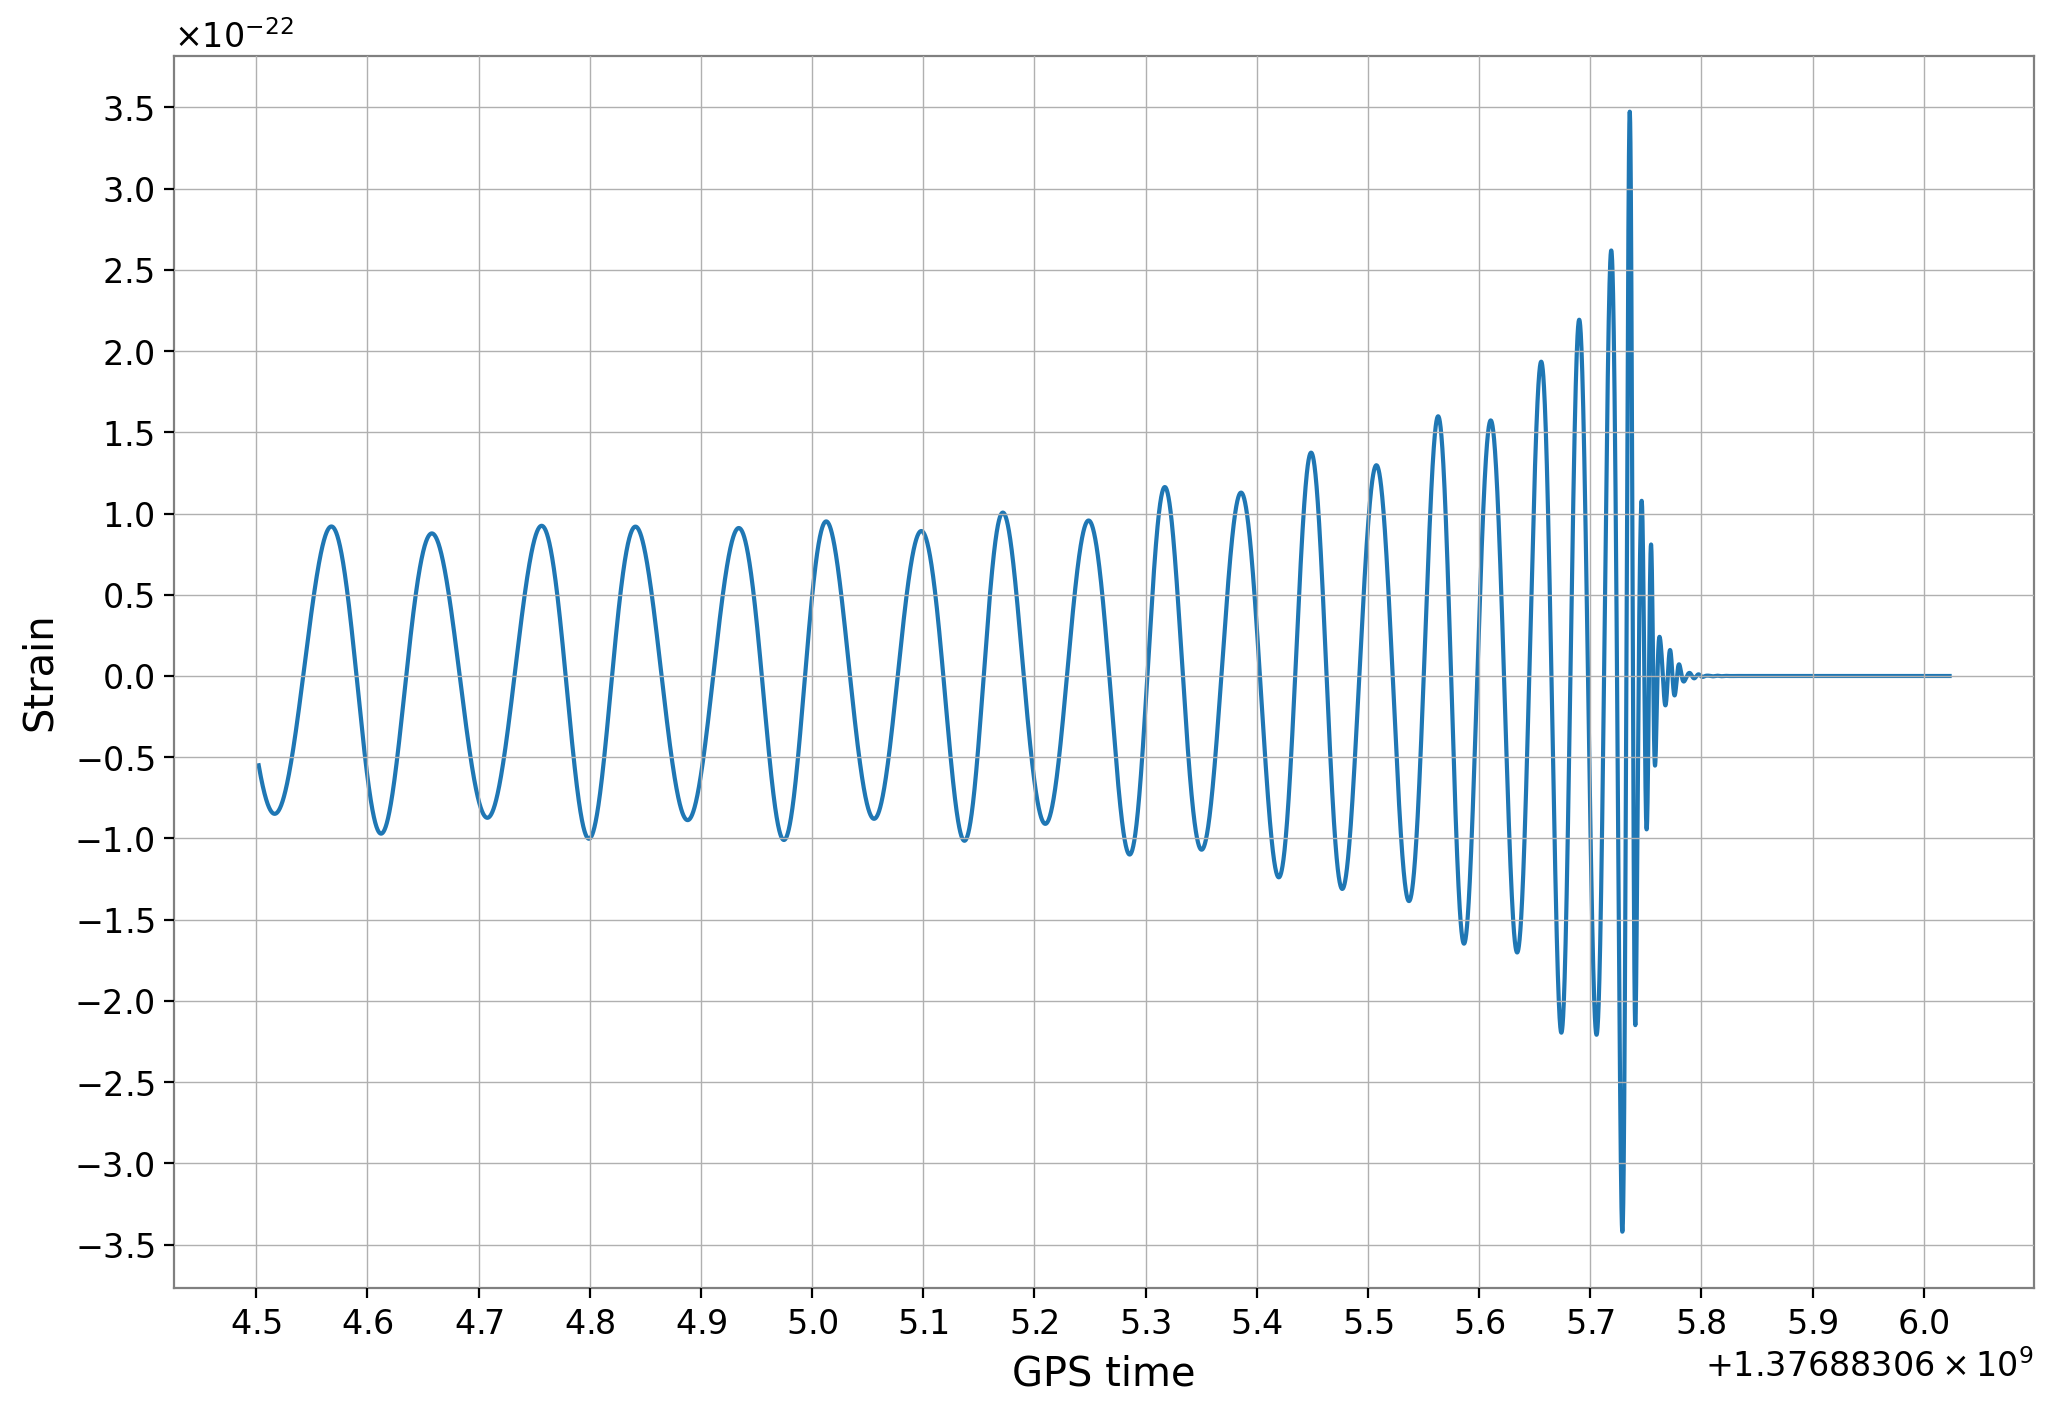

In [44]:
import matplotlib.ticker as ticker

fig = plt.figure(figsize=(12,8))
plt.plot(waveforms.times, waveforms)
plt.xlabel("GPS time")
plt.ylabel("Strain")
# 1. Get the current axes
ax = plt.gca()

# 2. Set the 0.1s tick marks
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5e-22))

plt.show()

plt.close()

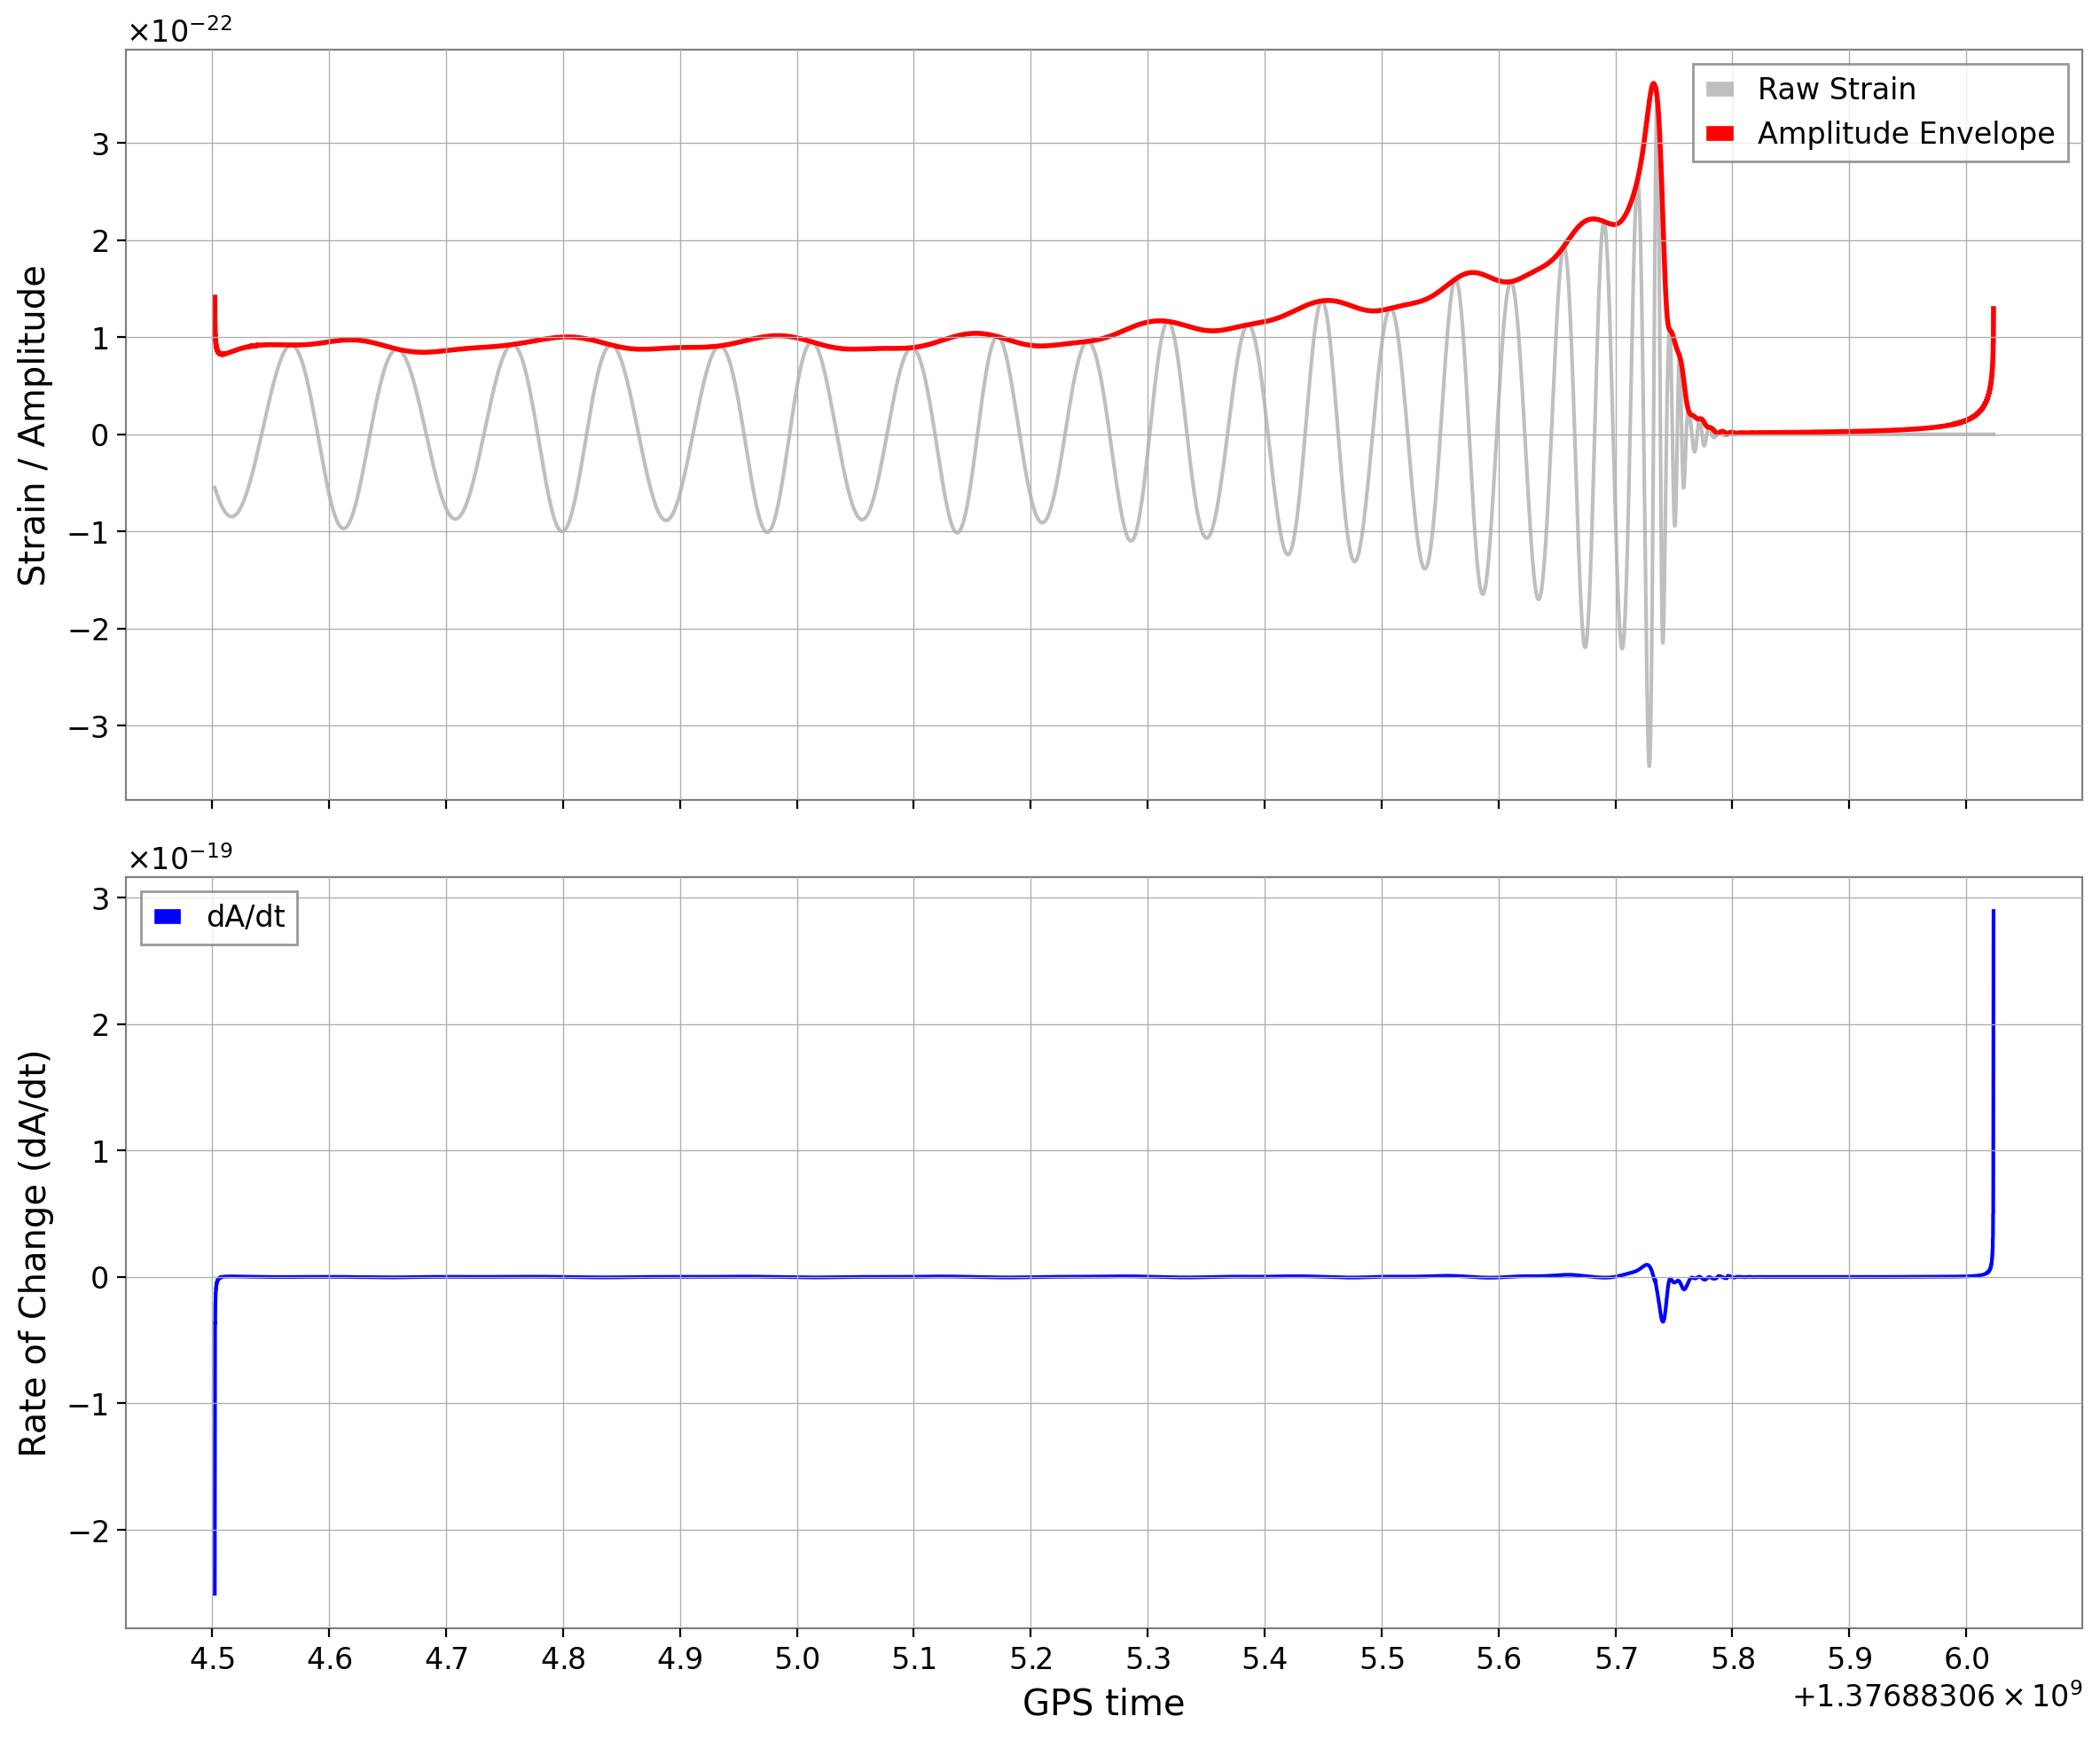

In [45]:
import numpy as np
from scipy.signal import hilbert
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Extract the amplitude envelope using the Hilbert transform
# (Assuming 'waveforms' behaves like a numpy array here)
analytic_signal = hilbert(waveforms)
amplitude_envelope = np.abs(analytic_signal)


# 2. Calculate the derivative of the envelope
# We use your existing delta_t to get the rate with respect to actual time
dA_dt = np.gradient(amplitude_envelope, delta_t)

# 3. Plot the results to verify!
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Top plot: Original strain with the new smooth envelope overlaid
ax1.plot(waveforms.times, waveforms, color='gray', label='Raw Strain', alpha=0.5)
ax1.plot(waveforms.times, amplitude_envelope, color='red', label='Amplitude Envelope', linewidth=2)
ax1.set_ylabel("Strain / Amplitude")
ax1.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax1.legend()

# Bottom plot: The rate of change of that amplitude
ax2.plot(waveforms.times, dA_dt, color='blue', label='dA/dt')
ax2.set_xlabel("GPS time")
ax2.set_ylabel("Rate of Change (dA/dt)")
ax2.legend()
ax2.xaxis.set_major_locator(ticker.MultipleLocator(0.1))

plt.tight_layout()
plt.show()
plt.close()

In [46]:
max_index = int(np.argmax(amplitude_envelope))

limited_range = dA_dt[:max_index+1]

max_dA_dt_index = np.argmax(limited_range)

print(dA_dt[max_dA_dt_index])

np.float64(9.650416007190029e-21)